
# DL Assignment 03

**Name: Shihab Shariar**

**Course Email: shihabshahriar543@gmail.com**  

# General Instruction

You must choose your own dataset.

The dataset must:

Be a supervised learning dataset (Regression or Binary Classification)

Contain at least 300 samples

Have at least 2 input features

Be in CSV format

You are NOT allowed to use Dataset or DataLoader.

You must implement everything manually.

# Question 01: [ Marks 05 ]

## Dataset Preparation

## Using your chosen dataset:

Load the dataset.

Perform necessary preprocessing:

Handle missing values (if any)

Encode categorical variables (if necessary)

Feature scaling (if needed)

Separate features (X) and target (y).

Convert them into NumPy arrays.

Convert them into PyTorch tensors.

Split into training and testing sets.

Clearly explain each preprocessing decision.

### Answer 01:


In [240]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# diabetes dataset from kaggle : https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
data = pd.read_csv("/content/diabetes.csv")

print(data.head())
print(data.shape)
print(data.info())
# print(data.describe())


# Handling zero values
zero_val_col = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "Age"]
for col in zero_val_col:
    data[col] = data[col].replace(0, data[col].median())

# separating features x and target y
x = data.drop("Outcome", axis=1).values
y = data["Outcome"].values


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose             

In [241]:
print(type(x_train))

# scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# numpy to tensor conversion
x_train_tensor = torch.from_numpy(x_train)
x_test_tensor = torch.from_numpy(x_test)
y_train_tensor = torch.from_numpy(y_train)
y_test_tensor = torch.from_numpy(y_test)

x_train_tensor = torch.tensor(x_train_tensor, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test_tensor, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_tensor, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_tensor, dtype=torch.float32)

print(type(x_train_tensor))

print(x_train_tensor.shape)
print(y_train_tensor.shape)
print(x_test_tensor.shape)
print(y_test_tensor.shape)

<class 'numpy.ndarray'>
<class 'torch.Tensor'>
torch.Size([614, 8])
torch.Size([614])
torch.Size([154, 8])
torch.Size([154])


/tmp/ipykernel_1255/3880061169.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train_tensor = torch.tensor(x_train_tensor, dtype=torch.float32)
/tmp/ipykernel_1255/3880061169.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_test_tensor = torch.tensor(x_test_tensor, dtype=torch.float32)
/tmp/ipykernel_1255/3880061169.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor = torch.tensor(y_train_tensor, dtype=torch.float32)
/tmp/ipykernel_1255/3880061169.py:17: UserWarning: To copy construct from a tensor, it is rec

In [242]:
x_train_tensor.shape[1]

8

I collected the a diabetes classification datset from kaggle as a csv file then load the file with pandas.
After loading I checked the statistics of the dataset and saw some columns contained 0 values which is wrong, impossible or unrealistic. So I replaced the zeros with the median of that column.
I separate the dataset to feature (x) and target (y) and splitted into x_train, x_test, y_tain, y_test as 80/20 ratio.
After splitting I applied scaling in x_train and x_test to train the model safely.
After all of this I converted the train and test sets into tensors and assigned their datatype as float32.
At last I checked the shapes to be sure everything was correctly done.

# Question 02: [ Marks 20 ]

## Design a neural network using nn.Module.

### The model must contain:

Input layer

At least one hidden layer

Output layer

Suitable activation function



## Justify:

Number of hidden neurons

Choice of activation function

Print  the total number of trainable parameters.


### Answer 02:


In [243]:
import torch.nn as nn
import torch.optim as optim

class MyExnn(nn.Module):

  def __init__(self, num_features):
    super().__init__()

    self.network = nn.Sequential(
        nn.Linear(num_features,16),
        nn.ReLU(),

        nn.Linear(16,8),
        nn.ReLU(),

        nn.Linear(8,1),
        nn.Sigmoid()
    )

  def forward(self, feature):
    out = self.network(feature)
    return out

In [244]:
model = MyExnn(x_train_tensor.shape[1])

In [245]:
!pip install torchinfo

from torchinfo import summary
summary(model, input_size=(1, x_train_tensor.shape[1]))

Layer (type:depth-idx)                   Output Shape              Param #
MyExnn                                   [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 16]                   144
│    └─ReLU: 2-2                         [1, 16]                   --
│    └─Linear: 2-3                       [1, 8]                    136
│    └─ReLU: 2-4                         [1, 8]                    --
│    └─Linear: 2-5                       [1, 1]                    9
│    └─Sigmoid: 2-6                      [1, 1]                    --
Total params: 289
Trainable params: 289
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

My designed nueral network MyExnn takes 8 input in the first input layer. The first hidden layer contains 16 neurons, the second hidden layer contains 8 neurons then our last input layer contains 1 neuron.

I used ReLU in both hidden layer to make the training faster. As well as ReLU also ensures there will be no vanishing gradient problem. As my network contains a single output neuron and predict binary class range between 0 to 1 , so I used sigmoid in the output layer.


Trainable params: 289

# Question 03: [ Marks 10 ]

Choose an appropriate loss function.

Choose an optimizer.

<br>

Justify your choices based on:

Regression vs Classification

Nature of the dataset

### Answer 03:

In [246]:
loss_fnc = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

The dataset I chose was a binary classification dataset to predict if a person has diabetes (1) or not (0).

Since it is a binary classification dataset and y is binary 0 or 1 so I used binary cross entropy loss (BCE) function.

I used Adam optimizer because it computes adaptive learning rates for each parameters through the whole training. I didn't use SDG because it applies fixed learning rate which I tested earlier and got very poor performance.

# Question 04: [ Marks 15 ]

## Implement a full training loop:

Forward pass

Loss computation

Backward pass

Parameter update

Gradient reset

### Requirements:

Train for at least 100 epochs.

Print loss every 10 epochs.

Store training loss history(You can pick your own Data Structure).

Explain clearly what happens in each step of the pipeline.

### Answer 04:

In [247]:
epochs = 100
loss_history = []

for epoch in range(epochs):

# forward pass
  y_pred = model(x_train_tensor)
# calculate loss
  loss = loss_fnc(y_pred, y_train_tensor.reshape(-1,1))
# reset gradient
  optimizer.zero_grad()
# backward pass
  loss.backward()
# update parameters
  optimizer.step()


  loss_history.append(loss.item())

  if (epoch+1) % 10 == 0:
    print(f"{epoch+1} ,  Loss = {loss.item()}")

10 ,  Loss = 0.7033426761627197
20 ,  Loss = 0.6825439929962158
30 ,  Loss = 0.6609851717948914
40 ,  Loss = 0.6382985711097717
50 ,  Loss = 0.6146957874298096
60 ,  Loss = 0.5911405682563782
70 ,  Loss = 0.5688477754592896
80 ,  Loss = 0.5488216876983643
90 ,  Loss = 0.5320326089859009
100 ,  Loss = 0.5186267495155334


In [248]:
print(loss_history)

[0.7211479544639587, 0.7192346453666687, 0.7172990441322327, 0.7153423428535461, 0.7133686542510986, 0.7113884687423706, 0.709399402141571, 0.7073929905891418, 0.7053741812705994, 0.7033426761627197, 0.7012984156608582, 0.6992447972297668, 0.6971854567527771, 0.6951005458831787, 0.6930109262466431, 0.6909187436103821, 0.6888308525085449, 0.6867338418960571, 0.6846391558647156, 0.6825439929962158, 0.6804385185241699, 0.6783230304718018, 0.676193356513977, 0.6740499138832092, 0.671896755695343, 0.6697282195091248, 0.6675511002540588, 0.6653684377670288, 0.6631865501403809, 0.6609851717948914, 0.6587691903114319, 0.6565417051315308, 0.6543062329292297, 0.6520556807518005, 0.6497911810874939, 0.647513747215271, 0.6452251076698303, 0.6429325342178345, 0.6406204104423523, 0.6382985711097717, 0.6359637379646301, 0.63362056016922, 0.6312716007232666, 0.6289183497428894, 0.6265559196472168, 0.6241905093193054, 0.6218233108520508, 0.6194521188735962, 0.6170749664306641, 0.6146957874298096, 0.612

The training loop iterates the dataset 100 times within the defined epochs.

Inside the training loop the model completes the forward pass to obtain a prediction then with the help of BCE function the loss is computed.

After computing loss the gradients get reset so that it should not add with the next gradient calculation. Next, backward pass is performed, for this, where how much trainable parameter need to change is calculated. Finally optimizer.step() updates all the weights and bias according to these whole calculations.

The loss_history list contains all the losses within 100 epochs.

As we are printing the loss every 10 epoch we can see see the loss is decreasing, it means the model is learning perfectly.

# Question 05: [ Marks 10 ]

## Evaluate the model on test data.

## For regression:

Report MSE and MAE


## For classification:

Report Accuracy

Compare training vs testing performance.

State whether the model is underfitting or overfitting.

### Answer 05:

In [249]:
epochs = 100
loss_history = []

for epoch in range(epochs):

  y_pred = model(x_train_tensor)

  train_loss = loss_fnc(y_pred, y_train_tensor.reshape(-1,1))

  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()

  with torch.no_grad():
      y_test_pred = model(x_test_tensor)
      test_loss = loss_fnc(y_test_pred, y_test_tensor.reshape(-1,1))



  if (epoch+1) % 10 == 0:
    loss_history.append(train_loss.item())
    print(f"{epoch+1} , Train Loss = {train_loss.item()} - Test loss : {test_loss}")

10 , Train Loss = 0.5074935555458069 - Test loss : 0.5172131061553955
20 , Train Loss = 0.4979443848133087 - Test loss : 0.5073679089546204
30 , Train Loss = 0.48934072256088257 - Test loss : 0.4995821714401245
40 , Train Loss = 0.48155370354652405 - Test loss : 0.49317580461502075
50 , Train Loss = 0.47471269965171814 - Test loss : 0.4876153767108917
60 , Train Loss = 0.4687274396419525 - Test loss : 0.48277902603149414
70 , Train Loss = 0.4634266197681427 - Test loss : 0.4782148599624634
80 , Train Loss = 0.4587036073207855 - Test loss : 0.4735225737094879
90 , Train Loss = 0.4544730484485626 - Test loss : 0.4689622223377228
100 , Train Loss = 0.450765997171402 - Test loss : 0.4651033878326416


In [250]:
from sklearn.metrics import accuracy_score
with torch.no_grad():
  test_out = model(x_test_tensor)
  pred = (test_out >= 0.5).float()
  accuracy = accuracy_score(
      y_test_tensor.numpy(),
      pred.numpy()
  )
  print(f"Test Accuracy = {accuracy}")

Test Accuracy = 0.7857142857142857


The model approximately got 78.57% test accuracy.

After training the model for 100 epochs :

At the end I got training loss 0.450... and test loss 0.465... we can see the test loss is slightly higher than the training loss. The difference is so significant that we can say the model with this test accuracy is not severely underfitted or overfitted.

# Question 06: [ Marks 20 ]

## Modify at least ONE of the following:

Learning rate

Number of hidden neurons

Number of epochs

### Train again and compare:

Convergence speed

Final performance

Explain how the change affected the model.

### Answer 06:

In [251]:

import torch.nn as nn
import torch.optim as optim

class MyExnn(nn.Module):

  def __init__(self, num_features):
    super().__init__()

    self.network = nn.Sequential(
        nn.Linear(num_features,16),
        nn.ReLU(),

        nn.Linear(16,8),
        nn.ReLU(),

        nn.Linear(8,1),
        nn.Sigmoid()
    )

  def forward(self, feature):
    out = self.network(feature)
    return out


model = MyExnn(x_train_tensor.shape[1])

loss_fnc = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 100

Train_loss = []
Test_loss = []
Epc = []

for epoch in range(epochs):

  y_pred = model(x_train_tensor)

  train_loss = loss_fnc(y_pred, y_train_tensor.reshape(-1,1))

  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()

  with torch.no_grad():
      y_test_pred = model(x_test_tensor)
      test_loss = loss_fnc(y_test_pred, y_test_tensor.reshape(-1,1))

  Train_loss.append(train_loss.item())
  Test_loss.append(test_loss.item())
  Epc.append(epoch+1)

  # print(f"{epoch+1} , Train Loss = {train_loss.item()} - Test loss{test_loss}")

  df = pd.DataFrame({
      "Epoch" : Epc,
      "Train Loss" : Train_loss,
      "Test Loss" : Test_loss
  })
print(df)

    Epoch  Train Loss  Test Loss
0       1    0.707209   0.690246
1       2    0.692902   0.678000
2       3    0.679138   0.666081
3       4    0.666048   0.654966
4       5    0.653603   0.643460
..    ...         ...        ...
95     96    0.377743   0.484935
96     97    0.376342   0.485705
97     98    0.374895   0.485879
98     99    0.373523   0.486026
99    100    0.372178   0.486250

[100 rows x 3 columns]


/tmp/ipykernel_1255/2847551717.py:3: MatplotlibDeprecationWarning: Passing label as a length 100 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df["Epoch"], df["Train Loss"], label = df["Train Loss"])
/tmp/ipykernel_1255/2847551717.py:4: MatplotlibDeprecationWarning: Passing label as a length 100 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df["Epoch"], df["Test Loss"], label = df["Test Loss"])


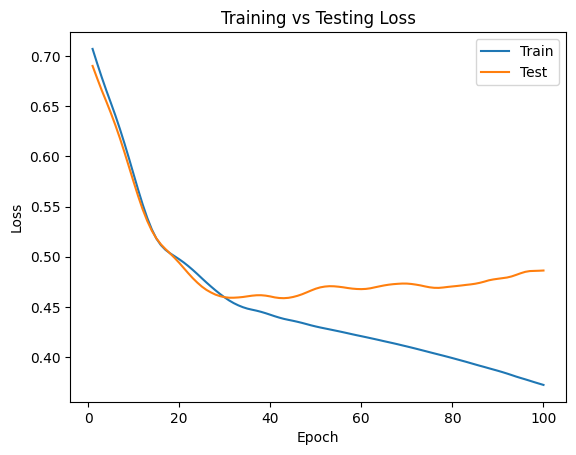

In [252]:
import matplotlib.pyplot as plt

plt.plot(df["Epoch"], df["Train Loss"], label = df["Train Loss"])
plt.plot(df["Epoch"], df["Test Loss"], label = df["Test Loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Testing Loss")
plt.legend(["Train","Test"] )
plt.show()



In [253]:
from sklearn.metrics import accuracy_score
with torch.no_grad():
  test_out = model(x_test_tensor)
  pred = (test_out >= 0.5).float()
  accuracy = accuracy_score(
      y_test_tensor.numpy(),
      pred.numpy()
  )
  print(f"Test Accuracy = {accuracy}")

Test Accuracy = 0.7597402597402597


With the exact same setup just changing the learning rate 0.001 to 0.01 The model showed a totally different result.

After same 100 epochs we can see train loss is 0.372... which is so much less than our previous setup's train loss 0.450... it means the model converged faster this time.

The test loss increased this time 0.465... to 0.486. We also can see the accuracy droped 78.57% to 75.97%, means the increase of learning rate makes the model to train fast but it make the model to perform worse during predicting unseen data.

If we see the plot where train loss is marked as blue line and test loss marked as orage line, we can see a huge gap started to form between them after passing approximately 30 to 32 epoch. This indicates the model is overfitted.



# Question 07: [ Marks 20 ]


# Training Analysis

Answer the following:

Why must gradients be reset every epoch?

What happens if learning rate is too high?

What happens if learning rate is too small?

Why do we define layers inside the constructor (__init__) and not inside forward()?


### Answer 07:

If we do not reset gredients in every epoch then the previous gradients keep adding. For this our whole training becomes incorrect.

If we set learning rate too high then our model may overshoot the optimal solution. This can be a cause of unstable traning.

If we set too small learning rate then our model takes long time to converge which also makes the training slow.

If we define the layers inside the forward() function then every time the model runs, new layer will be created and previously learned weights will be lost. The model will start lerning from the begining again and again.
So we define the layers inside the constructor __init__ and use forward() function only to describe how the input data moves through those layers to prevent the issue.